In [1]:
%pdb off

Automatic pdb calling has been turned OFF


In [2]:
%load_ext autoreload
%autoreload 2

import pipeline
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import count
import time
import pickle
from scipy.stats import spearmanr
from sklearn.manifold import TSNE
import shutil
import sys
import itertools
from collections import defaultdict
import geopandas as gpd
from tqdm.auto import tqdm
import plotly.io as pio
pio.renderers.default = "notebook"

seed = 21
vers = 'agg'
agg = False
weight = 'cov'

if vers == "6":
    fpath = Path('data/undir_trials/6h/thresholded_networks/0_network.txt')
    save_dir = Path(f'data/undir_trials/6h/tests/seed{seed}')
    data = Path('data/undir_trials/depnet_undirected.gz')
elif vers == '24':
    fpath = Path('data/undir_trials/24h/0_network_24h.txt')
    save_dir = Path(f'data/undir_trials/24h/tests/seed{seed}')
    data = Path('data/undir_trials/24h/depnet_undirected_24h.gz')
elif vers == 'agg':
    fpath = Path('data/agg/agg_network_24h_undir.pkl')
    save_dir = Path(f'data/agg/tests/seed{seed}')
    agg = True
    weight = 'num_occ'
else:
    print("Invalid version.")

save_dir.mkdir(parents=True, exist_ok=True)
print(f"Version: {vers} (agg={agg})")
print(f'Seed: {seed}')

Version: agg (agg=True)
Seed: 21


In [ ]:
# blank canvas for checking file structure if needed

### Thresholding and Building Network(s)

In [ ]:
# --- dependency distribution ---

# reading in + dealing with missing values
df = pd.read_csv(data)
df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
df = df.dropna(subset=['DEP'])

# sampling for performance
plot_data = df['DEP'].sample(100000)
print(plot_data.describe())

sns.displot(plot_data, bins=30, kde=True, stat='probability', log_scale=True)
plt.margins(x=0)

# --- num removed vs binned values ---

dep_nonzero = df.loc[df['DEP'] > 0, 'DEP'].sort_values().values
total_edges = len(df)
zero_edges = total_edges - len(dep_nonzero)

print(f"Total edges: {total_edges}")
print(f"Zero-DEP edges: {zero_edges}")
print(f"Nonzero DEP range: [{dep_nonzero.min():.2e}, {dep_nonzero.max():.2e}]")

# log-spaced bins across the nonzero DEP range
bins = np.logspace(np.log10(dep_nonzero.min()), np.log10(dep_nonzero.max()), 200)

# for each threshold, edges retained = nonzero edges with DEP >= threshold
edges_retained = len(dep_nonzero) - np.searchsorted(dep_nonzero, bins, side='left')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bins, edges_retained)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('DEP threshold')
ax.set_ylabel('Number of edges retained')
ax.set_title('Edges retained vs DEP threshold')

ax.axhline(y=1_000_000, color='r', linestyle='--', label='1M edges')
ax.axhline(y=10_000, color='orange', linestyle='--', label='10k edges')
ax.legend()
plt.show()

# find approximate thresholds
vals = []
for target, label in [(1_000_000, 'DEP_low (~1M)'), (10_000, 'DEP_high (~10k)')]:
    idx = np.argmin(np.abs(edges_retained - target))
    vals.append(bins[idx])
    print(f"{label}: DEP ≈ {bins[idx]:.6e}, edges retained = {edges_retained[idx]}")

DEP_low = vals[0]
DEP_high = vals[1]

In [ ]:
all = 0

# reloading df if needed
if 'df' not in globals():
    df = pd.read_csv(data)
    df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
    df = df.dropna(subset=['DEP'])

if all:
    # filtering
    DEP_range = df[df['DEP'].between(DEP_low, DEP_high)]
    # calculating thresholds with bounded range
    quantiles = np.quantile(DEP_range['DEP'], [0.25, 0.5, 0.75])
    thresholds = np.concatenate([[DEP_low], quantiles, [DEP_high]])

    # creating networks with original uncapped df
    for i, threshold in zip(count(0, 0.25), thresholds):
        # filter
        thresholded_df = df[df['DEP'] >= threshold]
        
        # save df directly
        filepath = f'data/undir_trials/thresholded_networks/{i}_network.txt'
        thresholded_df.to_csv(filepath, sep=' ', index=False, header=False)
        
        print(f"Saved {filepath} with {len(thresholded_df)} edges")
else:
    thresholded_df = df[df['DEP'] >= DEP_low]
    filepath = f'data/undir_trials/24h/network.txt'
    thresholded_df.to_csv(filepath, sep=' ', index=False, header=False)
    print(f"Saved {filepath} with {len(thresholded_df)} edges")

Saved data/undir_trials/24h/network.txt with 991526 edges


### Single Test Run Template

In [7]:
# --- new split if needed ---

print(f"Using seed: {seed}")
print(f"Version check: {vers}")

split_path = save_dir / f"split_{seed}.pkl"
train_path = save_dir / f"train_{seed}.txt"

if split_path.is_file():
    print(f"Split already exists for seed: {seed}. Exiting...")
    sys.exit()

G, train_neg, test_pos, test_neg = pipeline.prepare_data(
    fpath, frac=.25, seed=seed, weight=weight, agg=agg, meta=True,
    trainfile=train_path)

save_dir.mkdir(parents=True, exist_ok=True)
with open(split_path, 'wb') as f:
    pickle.dump((G, train_neg, test_pos, test_neg), f, pickle.HIGHEST_PROTOCOL)
print(f"Saved split → {split_path}")

Using seed: 21
Version check: agg


Sampling non-edges (fast):   0%|          | 0/1289541 [00:00<?, ?edge/s]

Sampling non-edges (fast):   0%|          | 0/3903472 [00:00<?, ?edge/s]

Wrote training graph: 15025 nodes, 3929892 edges
Saved split → data\agg\tests\seed21\split_21.pkl


In [ ]:
# --- run test ---

print(f"Using seed: {seed}")
print(f"Version check: {vers} (agg={agg})")

file_path = save_dir / f"split_{seed}.pkl"
with open(file_path, 'rb') as f:
            G, train_neg, test_pos, test_neg = pickle.load(f)
            
p, q, dim = 4, 0.25, 192
weighted = True
cat_threshold = 20
feats_list = [
        ['emb', 'geo'],
        ['emb', 'comm'],
        ['emb', 'comm', 'time'],
        ['emb', 'comm', 'time', 'income'],
        ['geo'],
        ['comm'],
        ['time'],
        ['income'],
        ['comm', 'time', 'income'],
        ['comm', 'time'],
        ['comm', 'income'],
        ['time', 'income']
]

for f in feats_list:
        print(f'NOW TESTING: {f}')
        feats = f
        auc, _ = pipeline.run_pipeline(save_dir / f"train_{seed}.txt", 
                                        train_neg, test_pos, test_neg, seed=seed,
                                        p=p, q=q, dim=192, workers=6, weighted=weighted,
                                        features=feats, cat_threshold=cat_threshold, G=G,
                                        agg=agg)

        feats_id = '_'.join(feats) if isinstance(feats, list) else feats
        with open(save_dir / f'score_seed{seed}-p{p}-q{q}-dim{dim}-w{weighted}-feats_{feats_id}-ct{cat_threshold}.txt', 'w') as f:
                f.write(str(auc))
                print('Score saved.')

Using seed: 21
Version check: agg (agg=True)
NOW TESTING: ['emb', 'geo']


  0%|          | 0/150160 [00:00<?, ?it/s]

Took 00:02:04.38 to generate walks


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Took 00:00:40.48 to train embeddings
Embeddings generated: 15016 nodes, dim=192
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
Training matrix: 7854394 samples x 193 features
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
[emb+geo (hadamard)]  AUC = 0.7168
Score saved.
NOW TESTING: ['emb', 'comm']


...

Took 00:00:42.94 to train embeddings
Embeddings generated: 15016 nodes, dim=192
Running Infomap...
Done.
Assigned 3 communities
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
Training matrix: 7854394 samples x 194 features
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
[emb+comm+time (hadamard)]  AUC = 0.7159
Score saved.
NOW TESTING: ['emb', 'comm', 'time', 'income']


  0%|          | 0/150160 [00:00<?, ?it/s]

Took 00:03:36.44 to generate walks


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Took 00:00:44.61 to train embeddings
Embeddings generated: 15016 nodes, dim=192
Running Infomap...
Done.
Assigned 3 communities
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
Training matrix: 7854394 samples x 195 features
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
[emb+comm+time+income (hadamard)]  AUC = 0.7415
Score saved.
NOW TESTING: ['geo']
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
Training matrix: 7858855 samples x 1 features
Category and census-based features invalid for aggregated network. Skipping.
Category and census-based features invalid for aggregated network. Skipping.
[geo]  AUC = 0.5059
Score saved.
NOW TESTING: ['comm']
Running Infomap...
Done.


### Distance-Controlled Negative Edge Sampling

Attribute check: ('22j-223@62k-26r-c5z', {'latitude': 41.957599, 'longitude': -70.665682, 'poi_type': 'Food', 'unique_visits': 174, 'total_visits': 311})
Nodes: 115355
Edges: 1015920


Sampling spatial non-edges:   0%|          | 0/57677 [00:00<?, ?edge/s]

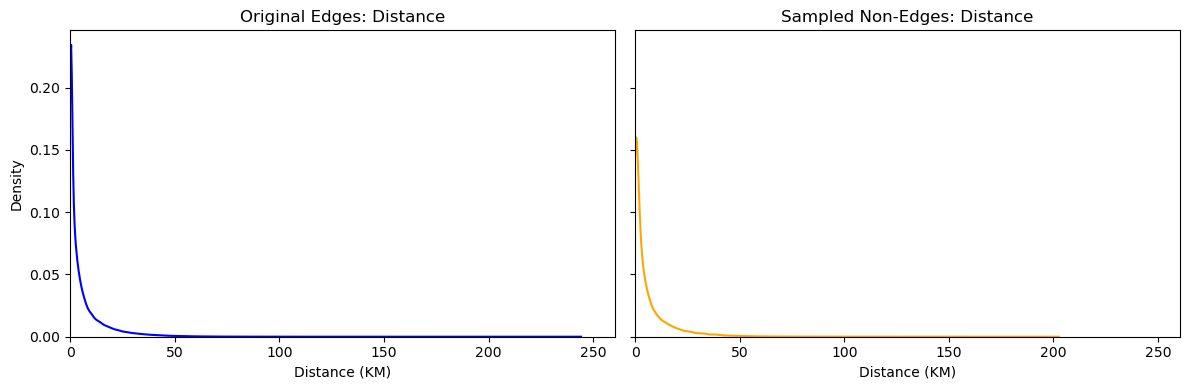

In [ ]:
# Plots/Verification

from pipeline import distribution_finder, sample_non_edges_dist_controlled, load
G = load(r'data/undir_trials/thresholded_networks/0_network.txt')

# Generate the sample 
distrs, sets = distribution_finder(G, bins=50)
dist_distr = distrs[0]
sample = sample_non_edges_dist_controlled(G, dist_distr, len(list(G.nodes())) // 2)

original_distances = list(nx.get_edge_attributes(G, 'DIST_KM').values())

locs = []
for u, v in sample:
    lat_u, lon_u = G.nodes[u]['latitude'], G.nodes[u]['longitude']
    lat_v, lon_v = G.nodes[v]['latitude'], G.nodes[v]['longitude']
    locs.append((lat_u, lon_u, lat_v, lon_v))

sampled_distances = [haversine((lat1, lon1), (lat2, lon2)) for (lat1, lon1, lat2, lon2) in locs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
pd.Series(original_distances).plot.kde(bw_method='scott', ax=axes[0], title='Original Edges: Distance', color='blue')
pd.Series(sampled_distances).plot.kde(bw_method='scott', ax=axes[1], title='Sampled Non-Edges: Distance', color='orange')
axes[0].set_xlabel('Distance (KM)')
axes[1].set_xlabel('Distance (KM)')
axes[0].set_xlim(left=0)
axes[1].set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(r'data\undir_trials\imgs\distance_distr_comp.png')
plt.show()

In [ ]:
# Re-running pipeline

# --- prep ---
fpath = Path(r'data/undir_trials/thresholded_networks/0_network.txt')
G, train_neg, test_pos, test_neg = pipeline.prepare_data(fpath)

# --- metadata only ---
auc_geo, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['geo'])
auc_cat, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['cat'])
auc_vis, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['visits'])
auc_geo_cat, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['geo', 'cat'])
auc_all_metadata, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['geo', 'cat', 'visits'])

# --- embeddings only ---
auc_emb, emb_map = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb'])

# --- embeddings + metadata ---
auc_emb_geo, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb', 'geo'], embedding_map=emb_map)
auc_emb_geo_cat, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb', 'geo', 'cat'], embedding_map=emb_map)
auc_all, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, G=G, features=['emb', 'geo', 'cat', 'visits'], embedding_map=emb_map)

# --- results table ---
results = [
    (['geo'],                          auc_geo),
    (['cat'],                          auc_cat),
    (['visits'],                       auc_vis),
    (['geo', 'cat'],                   auc_geo_cat),
    (['geo', 'cat', 'visits'],         auc_all_metadata),
    (['emb'],                          auc_emb),
    (['emb', 'geo'],                   auc_emb_geo),
    (['emb', 'geo', 'cat'],            auc_emb_geo_cat),
    (['emb', 'geo', 'cat', 'visits'],  auc_all),
]

df_results = pd.DataFrame(results, columns=['Features', 'AUC'])
df_results['Features'] = df_results['Features'].apply(lambda x: ' + '.join(x))
df_results['AUC'] = df_results['AUC'].round(4)

# flag embedding inclusion
df_results['Includes_Emb'] = df_results['Features'].str.contains('emb').map({True: 'with_emb', False: 'without_emb'})

In [ ]:
# AUC bar plot color-coded by embedding inclusion
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='AUC', y='Features', hue='Includes_Emb', dodge=False, palette={'with_emb':'tab:blue','without_emb':'tab:green'})
plt.title('AUC Scores by Feature Set (Distance-Controlled Negative Sampling)')
plt.xlabel('AUC')
plt.ylabel('Feature Set')
plt.xlim(left=0.5, right=1)
for i, value in enumerate(df_results['AUC']):
    plt.text(value + 0.001, i, f"{value:.4f}", va='center')
plt.legend(title='Includes Embedding')
plt.tight_layout()
plt.savefig('data/undir_trials/imgs/auc_by_feature_barplot.png')
plt.show()

### Sequential Hyperparameter Sweep

In [ ]:
# Sequential Hyperparameter Sweep: p → q → dim

# Saves the split to disk at the start so it survives kernel restarts.

sweep_dir = Path('data/undir_trials/hparam_sweep')
sweep_dir.mkdir(parents=True, exist_ok=True)

# Persist the split so it can be reloaded without re-running prepare_data
with open(sweep_dir / 'sweep_split.pkl', 'wb') as f:
    pickle.dump((G, train_neg, test_pos, test_neg), f, pickle.HIGHEST_PROTOCOL)
print(f"Split saved → {sweep_dir / 'sweep_split.pkl'}")

FPATH   = 'train.txt'
WORKERS = 8
MODE    = 'PreComp'   # matches the baseline cell

# Walk params that match the baseline defaults in run_pipeline
WALK_KWARGS = dict(num_walks=10, walk_length=80, window_size=10)

P_VALUES   = [0.25, 0.50, 1, 2, 4]
Q_VALUES   = [0.25, 0.50, 1, 2, 4]
DIM_VALUES = [64, 96, 160, 192]

def run_phase(param_name, param_values, fixed):
    fixed_str = ', '.join(f"{k}={v}" for k, v in fixed.items())
    print(f"\n{'='*60}")
    print(f"PHASE: sweeping {param_name}  |  fixed: {fixed_str}")
    print(f"  values: {param_values}")
    print(f"{'='*60}")

    rows = []
    for val in param_values:
        kw = {**fixed, param_name: val}
        print(f"\n  [{param_name}={val}] starting ...", flush=True)
        t0 = time.perf_counter()

        auc, _ = pipeline.run_pipeline(
            FPATH, train_neg, test_pos, test_neg,
            G=G, features=['emb'], mode=MODE, workers=WORKERS,
            **WALK_KWARGS, **kw
        )

        elapsed = time.perf_counter() - t0
        print(f"  [{param_name}={val}]  AUC = {auc:.4f}   ({elapsed/60:.1f} min)", flush=True)
        rows.append({**kw, 'auc': auc, 'time_min': elapsed / 60})

    df = pd.DataFrame(rows)
    best_val = df.loc[df['auc'].idxmax(), param_name]
    print(f"\n  --> Best {param_name} = {best_val}  (AUC = {df['auc'].max():.4f})")
    print(df[[param_name, 'auc', 'time_min']].to_string(index=False))
    return df, best_val

# ── Phase 1: p sweep ──────────────────────────────────────────
p_df, best_p = run_phase('p', P_VALUES, fixed={'q': 1, 'dim': 128})
with open(sweep_dir / 'phase1_p_sweep.pkl', 'wb') as f:
    pickle.dump(p_df, f, pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {sweep_dir / 'phase1_p_sweep.pkl'}")

# ── Phase 2: q sweep ──────────────────────────────────────────
q_df, best_q = run_phase('q', Q_VALUES, fixed={'p': best_p, 'dim': 128})
with open(sweep_dir / 'phase2_q_sweep.pkl', 'wb') as f:
    pickle.dump(q_df, f, pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {sweep_dir / 'phase2_q_sweep.pkl'}")

# ── Phase 3: dim sweep ────────────────────────────────────────
dim_df, best_dim = run_phase('dim', DIM_VALUES, fixed={'p': best_p, 'q': best_q})
with open(sweep_dir / 'phase3_dim_sweep.pkl', 'wb') as f:
    pickle.dump(dim_df, f, pickle.HIGHEST_PROTOCOL)
print(f"\nSaved → {sweep_dir / 'phase3_dim_sweep.pkl'}")

# ── Consolidate ───────────────────────────────────────────────
all_results = {
    'phase1_p':   p_df,
    'phase2_q':   q_df,
    'phase3_dim': dim_df,
    'best': {'p': best_p, 'q': best_q, 'dim': int(best_dim)},
}
with open(sweep_dir / 'all_sweep_results.pkl', 'wb') as f:
    pickle.dump(all_results, f, pickle.HIGHEST_PROTOCOL)

print(f"\n{'='*60}")
print("SWEEP COMPLETE")
print(f"  best p   = {best_p}")
print(f"  best q   = {best_q}")
print(f"  best dim = {int(best_dim)}")
print(f"  baseline (p=1, q=1, dim=128): AUC = {p_df.loc[p_df['p']==1, 'auc'].values[0]:.4f}")
print(f"  all results → {sweep_dir / 'all_sweep_results.pkl'}")
print(f"{'='*60}")

In [ ]:
sweep_dir = Path('data/undir_trials/hparam_sweep')
with open(sweep_dir / 'all_sweep_results.pkl', 'rb') as f:
    sweep_results = pickle.load(f)

p_df   = sweep_results['phase1_p']
q_df   = sweep_results['phase2_q']
dim_df = sweep_results['phase3_dim']
best   = sweep_results['best']

try:
    baseline = auc_emb
except NameError:
    baseline = 0.5896

phases = [
    (p_df,   'p',   f"p  (q=1, dim=128)",                        'tab:blue'),
    (q_df,   'q',   f"q  (p={best['p']}, dim=128)",              'tab:orange'),
    (dim_df, 'dim', f"dim  (p={best['p']}, q={best['q']})",      'tab:green'),
]

fig, axes = plt.subplots(3, 1, figsize=(8, 8))
fig.suptitle('Sequential Hyperparameter Sweep', fontsize=13, fontweight='bold')

for ax, (df, param, title, color) in zip(axes, phases):
    labels = [str(v) for v in df[param]]
    aucs   = df['auc'].values
    best_i = aucs.argmax()

    colors = [color] * len(aucs)
    colors[best_i] = 'gold'

    ax.barh(labels, aucs - 0.5, left=0.5, color=colors, edgecolor='white', height=0.55)

    ax.axvline(baseline, color='crimson', linestyle='--', linewidth=1.3,
               label=f'baseline  {baseline:.4f}')

    for i, val in enumerate(aucs):
        ax.text(val + 0.002, i, f'{val:.4f}',
                va='center', fontsize=8.5,
                fontweight='bold' if i == best_i else 'normal')

    ax.set_xlim(0.5, 1.0)
    ax.set_xlabel('AUC')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('data/undir_trials/imgs/hparam_sweep_results.png', bbox_inches='tight', dpi=150)
plt.show()

### Weighted (node2vec+)

In [ ]:
seed = 21
fpath = Path('data/undir_trials/thresholded_networks/0_network.txt')
BEST_PARAMS = dict(p=4, q=0.25, dim=192)

# function for efficiency
def run_weighted_test(weight, compress=False):
    print(f"Starting test: weight={weight}, compress={compress}")
    split_dir = Path(f'data/undir_trials/weight_trials/{weight}')
    split_dir.mkdir(parents=True, exist_ok=True)
    weightmode = 'log' if compress else 'reg'

    # read back in if already exists
    load_dir = split_dir / f'{weightmode}_split.pkl'
    if load_dir.is_file():
        print("Reading back from disk...")
        with open(load_dir, 'rb') as f:
            G, train_neg, test_pos, test_neg = pickle.load(f)
    else:
        G, train_neg, test_pos, test_neg = pipeline.prepare_data(fpath, seed=seed, compress=compress, weight=weight)
        with open(load_dir, 'wb') as f:
            pickle.dump((G, train_neg, test_pos, test_neg), f, pickle.HIGHEST_PROTOCOL)
        print(f"Saved split → {split_dir / f'{weightmode}_split.pkl'}")

    auc, _ = pipeline.run_pipeline('train.txt', train_neg, test_pos, test_neg, seed=seed,
                                **BEST_PARAMS, workers=6, weighted=True)

    with open(split_dir / f'{weightmode}_score.txt', 'w') as f:
        f.write(str(auc))

    # move + rename training graph to save it
    shutil.move('train.txt', split_dir / f'{weightmode}_train.txt')

    print('Saved score + training graph.\n')

# dep
run_weighted_test('dep')
run_weighted_test('dep', True)

# cov
run_weighted_test('cov')
run_weighted_test('cov', True)

# Agg Network

### Geographic Variance of Category Dependencies

In [ ]:
# --- geo-controlled dependency matrices ---

# bring in network
with open(fpath, 'rb') as f:
    G = pickle.load(f)

# list possible combos (sets prevent double-counting)
cats = set()
tracts = set()
for n in G.nodes():
    c, t = n.split('||')
    cats.add(c)
    tracts.add(t)
combos = list(itertools.combinations(sorted(cats), 2))
cat_to_idx = {cat: i for i, cat in enumerate(sorted(cats))}

# main loop
cat_dep_matrices = {}
missing_all = defaultdict(list)
for t in tqdm(tracts):
    selected = [n for n in G.nodes() if t in n]
    
    edge_dict = {}
    for u, v, attr in G.edges(data=True):
        if u in selected and v in selected:
            clean_u = u.split('||')[0]
            clean_v = v.split('||')[0]
            edge_dict[tuple(sorted((clean_u, clean_v)))] = attr
    
    missing = []
    cat_dep_matrix = np.zeros((len(cats), len(cats)))

    for combo in combos:
        normalized_combo = tuple(sorted(combo))
        attr = edge_dict.get(normalized_combo)
        
        if attr:
            dep = attr.get('DEP')
            if dep is not None: 
                idx0 = cat_to_idx[combo[0]]
                idx1 = cat_to_idx[combo[1]]
                cat_dep_matrix[idx0, idx1] = dep
                cat_dep_matrix[idx1, idx0] = dep
            else:
                print(f'No dep found for {combo} in tract {t}: something wrong back at agg_network')
        else:
            missing.append(combo)
            continue

    missing_all[t].append(combo)
    cat_dep_matrices[t] = cat_dep_matrix

# reshape to long format: one row per (tract, cat1, cat2)
rows = []
for t, mat in cat_dep_matrices.items():
    for c1, c2 in combos:
        i, j = cat_to_idx[c1], cat_to_idx[c2]
        rows.append({'tract': t, 'cat1': c1, 'cat2': c2, 'dep': mat[i, j]})

dep_df = pd.DataFrame(rows)

# save
dep_df.to_parquet(r'data/agg/cat_dep_long.parquet', index=False)
with open(r'data/agg/missing_combos.pkl', 'wb') as f:
    pickle.dump(missing_all, f)

print(f"Saved {len(dep_df)} rows — {dep_df['tract'].nunique()} tracts, {dep_df[['cat1','cat2']].drop_duplicates().shape[0]} combos")

In [5]:
dep_df.to_parquet(r'data/agg/cat_dep_long.parquet', index=False)
with open(r'data/agg/missing_combos.pkl', 'wb') as f:
    pickle.dump(missing_all, f)

print(f"Saved {len(dep_df)} rows — {dep_df['tract'].nunique()} tracts, {dep_df[['cat1','cat2']].drop_duplicates().shape[0]} combos")

Saved 195510 rows — 1029 tracts, 190 combos


In [ ]:
# === analysis ===

# import data
stats = pd.read_parquet('data/agg/cat_dep_long.parquet')
stats.columns = ['TRACT', 'cat1', 'cat2', 'DEP']
cbg_gdf = gpd.read_file('data/geo/tl_2025_25_bg.shp').to_crs('EPSG:4326')

# agg shapefile up to tract level
cbg_gdf['TRACT'] = cbg_gdf['GEOID'].str.slice(0, 11)
tract_gdf = cbg_gdf.dissolve(by='TRACT', aggfunc='first')
tract_gdf = tract_gdf.reset_index()

# --- plotting ---

# define groups
groupings = [
    
]

# function to plot specific combo or group of combos
def map_dep(to_plot, map_vers='combo', combo_type=None):
    
    if map_vers == 'single':
        # filter to where chosen cat is involved
        mapping_df = stats[stats['cat1'].eq(to_plot) | stats['cat2'].eq(to_plot)]
        mapping_df = mapping_df.groupby('TRACT')['DEP'].mean().reset_index()
        title_text = f"Average Visit Dependency of Combinations Involving {to_plot} by Census Tract"
    
    elif map_vers == 'combo':
        first, second = to_plot
        if combo_type == 'grouped':
            # filter to where cat1 is in first group and cat2 is in second
            mapping_df = stats[stats['cat1'].isin(first) & (stats['cat2'].isin(second))]
            mapping_df = mapping_df.groupby('TRACT')['DEP'].mean().reset_index()
            title_text = f"Average Visit Dependency: {first} → {second} by Census Tract"
        else:
            # filter to specific combination
            filtered_df = stats[(stats['cat1'] == first) & (stats['cat2'] == second)]
            mapping_df = filtered_df[['TRACT', 'DEP']]
            title_text = f"Visit Dependency: {first} → {second} by Census Tract"

    # merge + plot

    merged_gdf = tract_gdf.merge(mapping_df, on='TRACT')

    merged_gdf.plot(
        column='DEP', 
        cmap='Reds', 
        linewidth=0.4, 
        ax=ax, 
        edgecolor=".4",
        legend=True
    )
    
    plt.xticks(rotation=90)
    ax.set_title(title_text, fontsize=14, fontweight='bold', pad=15)
    ax.set_axis_off()
    plt.show()

In [ ]:
# identify which ones have the highest variance

stats = pd.read_parquet('data/agg/cat_dep_long.parquet')

with open(fpath, 'rb') as f:
    G = pickle.load(f)

cats = set()
for n in G.nodes():
    c, _ = n.split('||')
    cats.add(c)
combos = list(itertools.combinations(sorted(cats), 2))

for c1, c2 in combos:
    filtered_df = stats[(stats['cat1'] == c1) & (stats['cat2'] == c2)]
    

# for g in groupings:
#     pass